In this notebook we will show that our embedding-proximity-perturbation method produces more similar semantic sentences than context based methods.

The baseline methods we compare to are context based (such as bert and derivatives).

The evaluation method will be cosine similarity between the original sentence to the paraphrased one.

The dataset will be torchtext.datasets.WikiText-2

### Overview: Embedding-Proximity Perturbations

To analyze the local loss manifold, we explore the input neighborhood with semantically coherent variations that preserve meaning.

Formally, let $V$ be a token vocabulary, let $\mathbf{x_{1:n}} = \{x_i\}_{i=1}^n \in V^n$ be a textual input sequence, let $R_p(x_i, x_i') \in \{x_i, x_i'\}$ be a random replacement function with probability $p$, let $U(1,m)$ be a discrete uniform distribution over some $m \in \mathbb{N}$, let $x_i^{(j)} \in V$ be the $j$'th nearest neighbor of $x_i$ based on the corresponding embeddings' cosine similarity, denoted as $\mathrm{COSIM}(x_i, x_i')$, and let $K$ denote the number of sampled perturbed variants. 

Then the neighborhood set $S^K$ of $K$ perturbed variants is defined as:
$$
S^K = \Big\{ \{ R_p(x_i, x_i^{(j_i)}) \}_{i=1}^n \;\Big|\; j_i \sim U(1,m) \Big\}_{\alpha=1}^K
$$

Here, $S^K$ is a set of semantically similar variants, preserving the original input's meaning while introducing limited semantic variation, and providing diverse coverage of the local loss topology.
We use $S^K$ to compute first-order and second-order statistics over the evaluated model loss, including mean, variance, and volatility, which form the ILL feature vector components.

The embedding-proximity perturbation is detailed in Algorithm 1 and illustrated in Figure 1.

**Algorithm 1: Embedding-Proximity Perturbation**

**Require:** Input sequence $\mathbf{x} = \{x_1, \dots, x_n\}$, perturbation probability $p$, number of neighbors for each token $m$, number of perturbations $K$  
**Ensure:** Set of perturbed variants $S^K=\{\tilde{\mathbf{x}}_j\}_{j=1}^K$

1. For $k = 1$ to $K$:
   1. For $i = 1$ to $n$:
      1. Sample $j \sim U(1, m)$
      2. Let $x_i^{(j)}$ be the $j$th nearest neighbor of $x_i$ by cosine similarity
      3. Replace $x_i$ with $x_i^{(j)}$ with probability $p$
   2. Store perturbed sequence $\tilde{\mathbf{x}}_k = \{x_1', \dots, x_n'\}$
2. Return $S^K=\{\tilde{\mathbf{x}}_j\}_{j=1}^K$

we will try over different parameters of the EPP method

$P \in \{0.1, 0.3, 0.4, 0.5, 0.6, 0.7 \}$

$m \in \{1, 5, 10, 15, 20, 25, 30, 40, 50 \} $ 

and fix $K=1$

In [28]:
import os
import sys
import numpy as np
import torch
import warnings
from tqdm.auto import tqdm
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModel
from sentence_transformers import SentenceTransformer, util
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import time

warnings.filterwarnings("ignore")

# Setup paths
curr_dir = os.getcwd()  # Use current directory directly
PROJECT_DIR = os.path.join(curr_dir, '..', '..', '..')
sys.path.append(PROJECT_DIR)
sys.path.append(os.path.join(PROJECT_DIR, 'src'))

In [ ]:
class DataManager:
    """
    A class to manage saving figures and dataframes to a specified output directory.
    """
    shared_timestamp = None
    
    def __init__(self, output_dir, timestamp=None):
        """
        Initialize the DataManager with an output directory.
        
        Args:
            output_dir (str): Path to the directory where files will be saved.
            timestamp (str, optional): Timestamp string to append to filenames for uniqueness.
        """
        self.output_dir = output_dir
        self.output_dir = os.path.relpath(self.output_dir, os.getcwd())
        
        if DataManager.shared_timestamp is None:
            DataManager.shared_timestamp = timestamp if timestamp else time.strftime("%Y%m%d-%H%M%S")
            
        self.timestamp = DataManager.shared_timestamp
        os.makedirs(self.output_dir, exist_ok=True)
        print(f"saves results to output dir: {self.output_dir}")
    
    def save_fig(self, fig, filename, dpi=300, bbox_inches='tight', **kwargs):
        """
        Save a matplotlib figure to the output directory.
        
        Args:
            fig (matplotlib.figure.Figure): The figure to save.
            filename (str): Base filename (without extension).
            dpi (int): Resolution for the saved figure.
            bbox_inches (str): Bounding box setting.
            **kwargs: Additional arguments for fig.savefig.
        """
        filepath = os.path.join(self.output_dir, filename)
        fig.savefig(filepath, dpi=dpi, bbox_inches=bbox_inches, **kwargs)
        print(f"Figure saved to {filepath}")
    
    def save_df(self, df, filename, index=False, **kwargs):
        """
        Save a pandas DataFrame to the output directory as CSV.
        
        Args:
            df (pd.DataFrame): The DataFrame to save.
            filename (str): Base filename (without extension).
            index (bool): Whether to include the index in the CSV.
            **kwargs: Additional arguments for df.to_csv.
        """
        filepath = os.path.join(self.output_dir, f"{filename}.csv")
        df.to_csv(filepath, index=index, **kwargs)
        print(f"DataFrame saved to {filepath}")

In [ ]:
try:
    timestamp
except NameError:
    timestamp = time.strftime("%Y_%m_%d-%H_%M_%S")
print(f"Timestamp: {timestamp}")
output_dir = os.path.join(curr_dir, f'EPP_MLM_comp_ablation', f'{timestamp}')
data_manager = DataManager(output_dir, timestamp)

Timestamp: 2025_12_26-11_42_48
saves results to output dir: EPP_MLM_comp_ablation/2025_12_26-11_42_48


In [31]:
# Import the generate_neighbors function from utils
from src.utils import generate_neighbors

# Load sentence transformer for computing semantic similarity
sentence_model = SentenceTransformer('all-MiniLM-L6-v2')
print("Loaded sentence transformer model")

Loaded sentence transformer model


In [32]:
# Load WikiText-2 dataset
print("Loading WikiText-2 dataset...")
dataset = load_dataset("wikitext", "wikitext-2-raw-v1", split="test")

# Extract sentences and filter out short ones
sentences = []
sample_size = 1000
for item in dataset:
    text = item['text'].strip()
    if len(text.split()) > 10:  # Only keep sentences with more than 10 words
        sentences.append(text)
        if len(sentences) >= sample_size:  # Limit to sample_size for efficiency
            break

print(f"Loaded {len(sentences)} sentences from WikiText-2")

Loading WikiText-2 dataset...


Loaded 1000 sentences from WikiText-2


In [33]:
# sentences = sentences[320:340]

In [34]:
# Load tokenizer for generating neighbors
tokenizer = AutoTokenizer.from_pretrained("distilgpt2")
print("Loaded tokenizer")

Loaded tokenizer


In [35]:
cosine_similarities_file = os.path.join(PROJECT_DIR, 'models', 'gpt2', 'embeddings', 'token_knn_mapping_70_cosine.pth')
if not os.path.exists(cosine_similarities_file):
        raise FileNotFoundError(f"Cosine similarities file not found at {cosine_similarities_file}")
    
cosine_similarities = torch.load(cosine_similarities_file)
print("Loaded cosine similarities")

Loaded cosine similarities


In [ ]:

def apply_embedding_proximity_perturbation(text, tokenizer, p, m, K=1, U=False):
    """
    Apply Embedding-Proximity Perturbation (EPP) to a text.
    
    Args:
        text: Input text string
        tokenizer: Tokenizer to use
        p: Perturbation probability
        m: Distance parameter for neighbor selection
        K: Number of perturbed variants to generate
    
    Returns:
        List of perturbed text variants
    """
    perturbed_variants = []
    
    strategy = {
            'method': 'token_embedding_proximity',
            'n_tokens': p,
            'max_neighbors': K,
            'peak_top_k': m
        }
    if U:
        m = list(range(m))
    variants = generate_neighbors(text=text,
                                            model=None,
                                            tokenizer=tokenizer,
                                            cosine_similarities=cosine_similarities,
                                            strategy=strategy
                                            )
    variants = variants[1:]
    perturbed_variants = [variant['text'] for variant in variants]
    
    return perturbed_variants

print("EPP function defined")

EPP function defined


In [37]:
def compute_semantic_similarity(original_text, perturbed_text, model):
    """
    Compute cosine similarity between original and perturbed text using sentence embeddings.
    
    Args:
        original_text: Original sentence
        perturbed_text: Perturbed sentence
        model: SentenceTransformer model
    
    Returns:
        Cosine similarity score
    """
    embeddings = model.encode([original_text, perturbed_text], convert_to_tensor=True)
    similarity = torch.cosine_similarity(embeddings[0], embeddings[1], dim=0).item()

    return similarity

print("Similarity function defined")

Similarity function defined


In [38]:
# Define parameter ranges
P_values = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7]
m_values = [1, 5, 10, 15, 20, 25, 30, 35, 40, 50, 70]
K = 1  # Fixed as per description

print(f"Testing {len(P_values)} perturbation probabilities: {P_values}")
print(f"Testing {len(m_values)} neighbor counts: {m_values}")
print(f"K (variants per config) = {K}")

Testing 6 perturbation probabilities: [0.2, 0.3, 0.4, 0.5, 0.6, 0.7]
Testing 11 neighbor counts: [1, 5, 10, 15, 20, 25, 30, 35, 40, 50, 70]
K (variants per config) = 1


In [39]:
def run_experiments(sentences, tokenizer, P_values, m_values, K, sample_size=100, MLM_model=None):
    """
    Run experiments to compute semantic similarities for different perturbation parameters.
    
    Args:
        sentences: List of input sentences
        tokenizer: Tokenizer for generating neighbors (used for both EPP and MLM)
        P_values: List of perturbation probabilities
        m_values: List of neighbor counts
        K: Number of perturbed variants to generate
        sample_size: Number of sentences to sample for efficiency
    
    Returns:
        List of results dictionaries containing p, m, and similarities
    """
    results = []
    # Sample a subset of sentences for efficiency
    sample_size = min(sample_size, len(sentences))
    sample_sentences = sentences[:sample_size]

    print(f"\nRunning experiments on {sample_size} sentences with {'MLM perturbation' if MLM_model else 'EPP perturbation'}.")
    print("This may take a few minutes...\n")
    
    perturb_function = apply_embedding_proximity_perturbation if MLM_model is None else apply_mlm_perturbation  # Placeholder for MLM-based function

    for p in tqdm(P_values, desc="Perturbation probability"):
        for m in tqdm(m_values, desc=f"Neighbors (p={p})", leave=False):
            similarities = []
            
            for idx, sentence in tqdm(enumerate(sample_sentences), total=len(sample_sentences), desc=f"Sentences (p={p}, m={m})", leave=False):
                try:
                    # Generate perturbed variant
                    max_attempts = 10
                    for i in range(max_attempts):
                        if MLM_model is None:
                            perturbed = perturb_function(
                                sentence, tokenizer, p, m, K
                            )
                        else:
                            perturbed = perturb_function(
                                sentence, tokenizer, MLM_model, p, m, K
                            )
                        if perturbed and len(perturbed) >= 1 and perturbed[0] != sentence:
                            break 
                        elif i == max_attempts - 1:
                            perturbed = None
                    
                    if perturbed:
                        # Compute similarity
                        sim = compute_semantic_similarity(
                            sentence, perturbed[0], sentence_model
                        )
                        similarities.append(sim)
                except Exception as e:
                    err_msg = str(e)
                    tqdm.write(f"Error processing sentence: {idx=}, error: {err_msg}")
                    # Skip problematic sentences
                    tqdm.write(f"Error processing sentence: {idx=}")
                    continue
            
            # Store results
            if similarities:
                results.append(
                    {
                        'p': p,
                        'm': m,
                        'mean_similarity': np.mean(similarities),
                        'std_similarity': np.std(similarities),
                        'min_similarity': np.min(similarities),
                        'max_similarity': np.max(similarities),
                        'n_samples': len(similarities)
                    }
                    
                )

    print(f"\nCompleted {len(results)} experiments")
    return results

results = run_experiments(
    sentences = sentences,
    tokenizer = tokenizer,
    P_values = P_values,
    m_values = m_values,
    K = K,
    sample_size = sample_size
)


Running experiments on 1000 sentences with EPP perturbation.
This may take a few minutes...



Perturbation probability:   0%|          | 0/6 [00:00<?, ?it/s]

Neighbors (p=0.2):   0%|          | 0/11 [00:00<?, ?it/s]

Sentences (p=0.2, m=1):   0%|          | 0/1000 [00:00<?, ?it/s]

Sentences (p=0.2, m=5):   0%|          | 0/1000 [00:00<?, ?it/s]

...

Sentences (p=0.7, m=35):   0%|          | 0/1000 [00:00<?, ?it/s]

Sentences (p=0.7, m=40):   0%|          | 0/1000 [00:00<?, ?it/s]

Sentences (p=0.7, m=50):   0%|          | 0/1000 [00:00<?, ?it/s]

Sentences (p=0.7, m=70):   0%|          | 0/1000 [00:00<?, ?it/s]


Completed 60 experiments


In [52]:
# Convert results to DataFrame for easy analysis
df_results = pd.DataFrame(results)
print(f"\nShape: {df_results.shape}")
print(f"\nBasic statistics:")
print(df_results[['mean_similarity', 'std_similarity']].describe())

# Save results to CSV for future reference
data_manager.save_df(df_results, 'epp_ablation_results.csv')


Shape: (60, 7)

Basic statistics:
       mean_similarity  std_similarity
count        60.000000       60.000000
mean          0.710336        0.096108
std           0.119457        0.015392
min           0.481378        0.059680
25%           0.604453        0.087054
50%           0.719182        0.098906
75%           0.804431        0.108904
max           0.904887        0.117835
DataFrame saved to EPP_MLM_comp_ablation/2025_12_26-11_42_48_1000_samp/epp_ablation_results.csv.csv


Figure saved to EPP_MLM_comp_ablation/2025_12_26-11_42_48/epp_similarity_heatmap.png


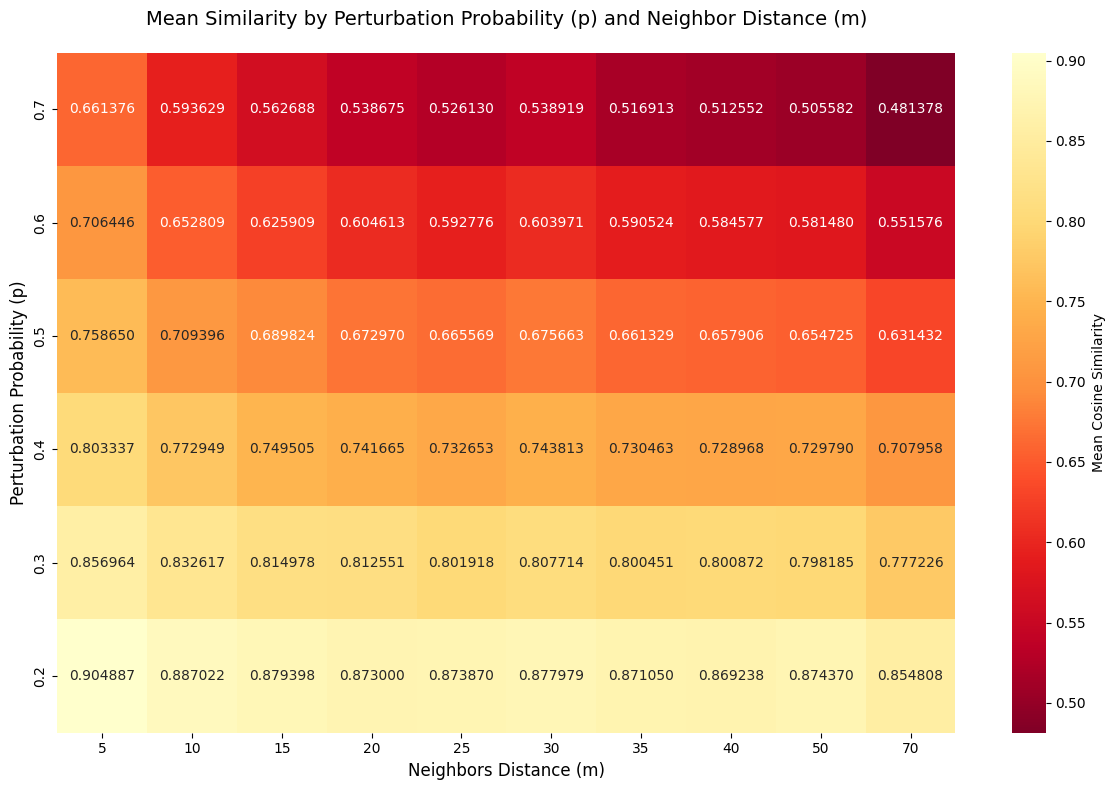

In [41]:
def create_similarity_heatmap(df_results, title, xlabel, ylabel, filename, cmap='YlOrRd_r'):
    """
    Create and save a heatmap showing mean similarity across parameters.
    
    Args:
        df_results: DataFrame with columns 'p', 'm', 'mean_similarity'
        title: Title for the heatmap
        xlabel: Label for x-axis
        ylabel: Label for y-axis
        filename: Filename to save the plot
        cmap: Colormap for the heatmap
    """
    pivot_table = df_results.pivot(index='p', columns='m', values='mean_similarity')
    pivot_table = pivot_table.sort_index(ascending=False)  # Sort p values descending so smallest is at bottom

    plt.figure(figsize=(12, 8))
    sns.heatmap(pivot_table, annot=True, fmt='.6f', cmap=cmap, cbar_kws={'label': 'Mean Cosine Similarity'})
    plt.title(title, fontsize=14, pad=20)
    plt.xlabel(xlabel, fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    plt.tight_layout()
    data_manager.save_fig(plt.gcf(), filename)
    plt.show()


create_similarity_heatmap(
    df_results=df_results,
    title='Mean Similarity by Perturbation Probability (p) and Neighbor Distance (m)',
    xlabel='Neighbors Distance (m)',
    ylabel='Perturbation Probability (p)',
    filename='epp_similarity_heatmap.png'
)

In [42]:
import numpy as np

# Sensitivity for p (fixed m, vary p)
p_sensitivities = []
for m_val in df_results['m'].unique():
    subset = df_results[df_results['m'] == m_val]
    if len(subset) > 1:
        p_sensitivities.append(subset['mean_similarity'].std())
avg_p_sensitivity = np.mean(p_sensitivities) if p_sensitivities else 0

# Sensitivity for m (fixed p, vary m)
m_sensitivities = []
for p_val in df_results['p'].unique():
    subset = df_results[df_results['p'] == p_val]
    if len(subset) > 1:
        m_sensitivities.append(subset['mean_similarity'].std())
avg_m_sensitivity = np.mean(m_sensitivities) if m_sensitivities else 0

print(f"Average sensitivity for p: {avg_p_sensitivity:.6f}")
print(f"Average sensitivity for m: {avg_m_sensitivity:.6f}")
print(f"More sensitive parameter: {'p' if avg_p_sensitivity > avg_m_sensitivity else 'm'}")

Average sensitivity for p: 0.124712
Average sensitivity for m: 0.031959
More sensitive parameter: p


Figure saved to EPP_MLM_comp_ablation/2025_12_26-11_42_48_1000_samp/epp_cosine_similarity_line_plot.png


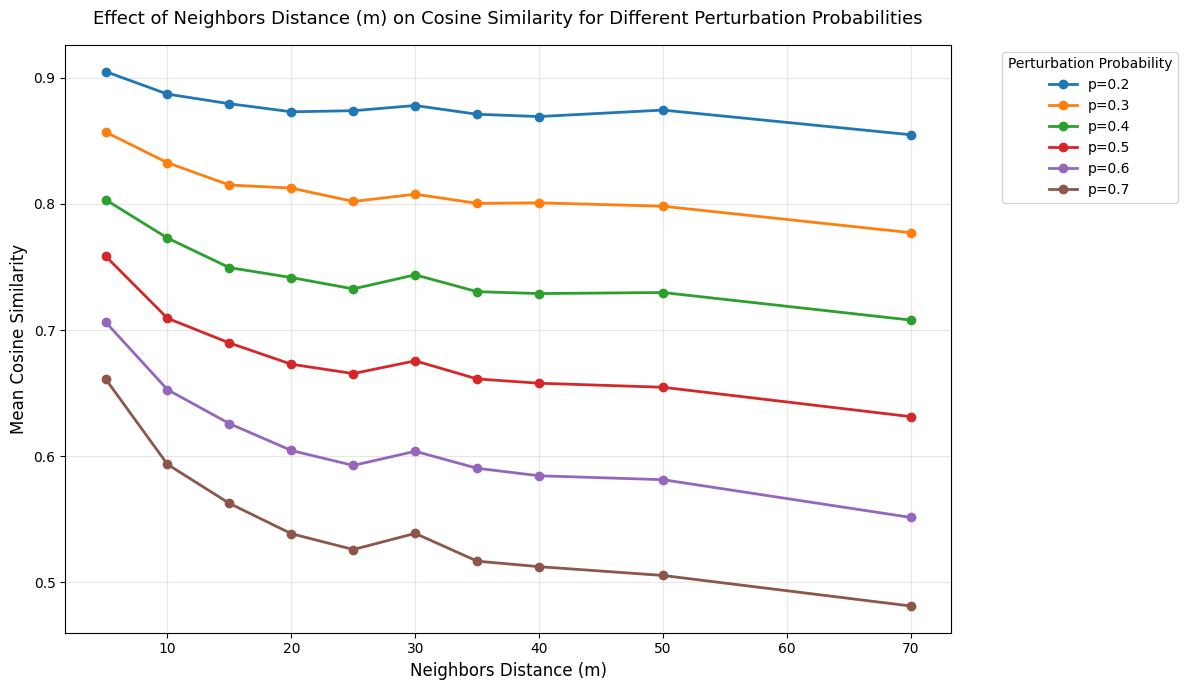

In [58]:
def create_similarity_line_plot(df_results, key, values, xlabel, ylabel, title, filename):
    """
    Create and save a line plot showing how similarity changes with m for different p values.
    
    Args:
        df_results: DataFrame with columns 'p', 'm', 'mean_similarity'
        key: Column name to filter values on
        values: List of values to plot for the specified key
        xlabel: Label for x-axis
        ylabel: Label for y-axis
        title: Title for the plot
        filename: Filename to save the plot
    """
    plt.figure(figsize=(12, 7))

    for v in values:
        subset = df_results[df_results[key] == v]
        plt.plot(subset['m'], subset['mean_similarity'], marker='o', label=f'{key}={v}', linewidth=2)

    plt.xlabel(xlabel, fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    plt.title(title, fontsize=13, pad=15)
    plt.legend(title='Perturbation Probability', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    data_manager.save_fig(plt.gcf(), filename)
    plt.show()
    
# Example usage:
create_similarity_line_plot(
    df_results=df_results,
    key='p',
    values=P_values,
    xlabel='Neighbors Distance (m)',
    ylabel='Mean Cosine Similarity',
    title='Effect of Neighbors Distance (m) on Cosine Similarity for Different Perturbation Probabilities',
    filename='epp_cosine_similarity_line_plot.png'
)

In [ ]:
def create_similarity_3d_plot_interactive(
    df_results,
    title,
    xlabel,
    ylabel,
    zlabel,
    filename_html=None,
    cmap='Viridis',
    marker_size=6,
    initial_view='left',   # new: 'left'|'right'|'front'|'auto'
    add_view_buttons=True,  # new: add small UI buttons to switch camera
):
    """
    Create an interactive 3D plot (plotly) where x=m, y=p and z=mean_similarity.
    Supports initial camera view selection and optional small view buttons.
    """
    import plotly.graph_objects as go
    import matplotlib.tri as mtri
    import os

    df = df_results[['m', 'p', 'mean_similarity']].dropna()
    xs = df['m'].astype(float).values
    ys = df['p'].astype(float).values
    zs = df['mean_similarity'].astype(float).values

    if len(xs) == 0:
        raise ValueError("No valid data points to plot.")

    # predefined cameras (eye positions) -> left view places x negative so zlabel faces left
    cameras = {
        'left': dict(eye=dict(x=-1.5, y=1.25, z=0.8)),
        'right': dict(eye=dict(x=1.5, y=1.25, z=0.8)),
        'front': dict(eye=dict(x=0.0, y=2.5, z=0.8)),
        'top': dict(eye=dict(x=0.0, y=0.8, z=3.0)),
    }
    initial_camera = cameras.get(initial_view, cameras['left'])

    fig = go.Figure()

    # Try triangulation to create a mesh; fallback to scatter only
    try:
        tri = mtri.Triangulation(xs, ys)
        if hasattr(tri, "triangles") and len(tri.triangles) > 0:
            i, j, k = tri.triangles.T
            fig.add_trace(
                go.Mesh3d(
                    x=xs, y=ys, z=zs, i=i, j=j, k=k,
                    intensity=zs, colorscale=cmap, opacity=0.6,
                    hovertemplate="m=%{x}<br>p=%{y}<br>sim=%{z:.4f}<extra></extra>",
                    name="mesh", showscale=True,
                )
            )
    except Exception:
        pass

    fig.add_trace(
        go.Scatter3d(
            x=xs, y=ys, z=zs, mode='markers',
            marker=dict(size=marker_size, color=zs, colorscale=cmap, colorbar=dict(title=zlabel)),
            hovertemplate="m=%{x}<br>p=%{y}<br>sim=%{z:.4f}<extra></extra>",
            name="points",
        )
    )

    # layout & camera
    fig.update_layout(
        title=title,
        scene=dict(
            xaxis_title=xlabel,
            yaxis_title=ylabel,
            zaxis_title=zlabel,
            camera=initial_camera,
        ),
        margin=dict(l=0, r=0, b=0, t=40),
        legend=dict(yanchor="top", y=0.95, xanchor="left", x=0.02),
    )

    # optional buttons to switch views interactively
    if add_view_buttons:
        updatemenus = [
            dict(
                type="buttons",
                direction="left",
                x=0.02,
                y=1.03,
                showactive=True,
                buttons=[
                    dict(label="Left",
                         method="relayout",
                         args=[{"scene.camera": cameras['left']}]),
                    dict(label="Right",
                         method="relayout",
                         args=[{"scene.camera": cameras['right']}]),
                    dict(label="Front",
                         method="relayout",
                         args=[{"scene.camera": cameras['front']}]),
                    dict(label="Top",
                         method="relayout",
                         args=[{"scene.camera": cameras['top']}]),
                ],
            )
        ]
        fig.update_layout(updatemenus=updatemenus)

    if filename_html:
        outpath = os.path.join(data_manager.output_dir, filename_html)
        fig.write_html(outpath)
        print(f"Interactive plot saved to {outpath}")

    fig.show()

# Example usage (initial view set to 'left' so zlabel is readable when you tilt left):
create_similarity_3d_plot_interactive(
    df_results=df_results,
    title='EPP Mean Cosine Similarity (interactive)',
    xlabel='Neighbors Distance (m)',
    ylabel='Perturbation Probability (p)',
    zlabel='Mean Cosine Similarity',
    filename_html='epp_similarity_3d_interactive.html',
    initial_view='left',
    add_view_buttons=True
)


Interactive plot saved to EPP_MLM_comp_ablation/2025_12_26-11_42_48/epp_similarity_3d_interactive.html


In [47]:
def create_similarity_3d_plot_interactive(
    df_results,
    title,
    xlabel,
    ylabel,
    zlabel,
    filename_html=None,
    cmap='Viridis',
    marker_size=6,
    initial_view='left',   # new: 'left'|'right'|'front'|'auto'
    add_view_buttons=True,  # new: add small UI buttons to switch camera
):
    """
    Create an interactive 3D plot (plotly) where x=m, y=p and z=mean_similarity.
    Supports initial camera view selection and optional small view buttons.
    """
    import plotly.graph_objects as go
    import matplotlib.tri as mtri
    import os

    df = df_results[['m', 'p', 'mean_similarity']].dropna()
    xs = df['m'].astype(float).values
    ys = df['p'].astype(float).values
    zs = df['mean_similarity'].astype(float).values

    if len(xs) == 0:
        raise ValueError("No valid data points to plot.")

    # predefined cameras (eye positions) -> left view places x negative so zlabel faces left
    cameras = {
        'left': dict(eye=dict(x=-1.5, y=1.25, z=0.8)),
        'right': dict(eye=dict(x=1.5, y=1.25, z=0.8)),
        'front': dict(eye=dict(x=0.0, y=2.5, z=0.8)),
        'top': dict(eye=dict(x=0.0, y=0.8, z=3.0)),
    }
    initial_camera = cameras.get(initial_view, cameras['left'])

    fig = go.Figure()

    # Try triangulation to create a mesh; fallback to scatter only
    try:
        tri = mtri.Triangulation(xs, ys)
        if hasattr(tri, "triangles") and len(tri.triangles) > 0:
            i, j, k = tri.triangles.T
            fig.add_trace(
                go.Mesh3d(
                    x=xs, y=ys, z=zs, i=i, j=j, k=k,
                    intensity=zs, colorscale=cmap, opacity=0.6,
                    hovertemplate="m=%{x}<br>p=%{y}<br>sim=%{z:.4f}<extra></extra>",
                    name="mesh", showscale=True,
                )
            )
    except Exception:
        pass

    fig.add_trace(
        go.Scatter3d(
            x=xs, y=ys, z=zs, mode='markers',
            marker=dict(size=marker_size, color=zs, colorscale=cmap, colorbar=dict(title=zlabel)),
            hovertemplate="m=%{x}<br>p=%{y}<br>sim=%{z:.4f}<extra></extra>",
            name="points",
        )
    )

    # layout & camera
    fig.update_layout(
        title=title,
        scene=dict(
            xaxis_title=xlabel,
            yaxis_title=ylabel,
            zaxis_title=zlabel,
            camera=initial_camera,
            # Remove walls and set axis lines to red
            xaxis=dict(showbackground=False, linecolor='red'),
            yaxis=dict(showbackground=False, linecolor='red'),
            zaxis=dict(showbackground=False, linecolor='red'),
            bgcolor='white',  # or 'rgba(0,0,0,0)' for transparent
        ),
        margin=dict(l=0, r=0, b=0, t=40),
        legend=dict(yanchor="top", y=0.95, xanchor="left", x=0.02),
    )

    # optional buttons to switch views interactively
    if add_view_buttons:
        updatemenus = [
            dict(
                type="buttons",
                direction="left",
                x=0.02,
                y=1.03,
                showactive=True,
                buttons=[
                    dict(label="Left",
                         method="relayout",
                         args=[{"scene.camera": cameras['left']}]),
                    dict(label="Right",
                         method="relayout",
                         args=[{"scene.camera": cameras['right']}]),
                    dict(label="Front",
                         method="relayout",
                         args=[{"scene.camera": cameras['front']}]),
                    dict(label="Top",
                         method="relayout",
                         args=[{"scene.camera": cameras['top']}]),
                ],
            )
        ]
        fig.update_layout(updatemenus=updatemenus)

    if filename_html:
        outpath = os.path.join(data_manager.output_dir, filename_html)
        fig.write_html(outpath)
        print(f"Interactive plot saved to {outpath}")

    fig.show()
    
    
# Example usage (initial view set to 'left' so zlabel is readable when you tilt left):
create_similarity_3d_plot_interactive(
    df_results=df_results,
    title='EPP Mean Cosine Similarity (interactive)',
    xlabel='Neighbors Distance (m)',
    ylabel='Perturbation Probability (p)',
    zlabel='Mean Cosine Similarity',
    filename_html='epp_similarity_3d_interactive.html',
    initial_view='left',
    add_view_buttons=True
)

Interactive plot saved to EPP_MLM_comp_ablation/2025_12_26-11_42_48/epp_similarity_3d_interactive.html


In [17]:
# Find optimal parameters (highest mean similarity)
best_config = df_results.loc[df_results['mean_similarity'].idxmax()]
print("\n" + "="*60)
print("OPTIMAL CONFIGURATION:")
print("="*60)
print(f"Perturbation Probability (p): {best_config['p']}")
print(f"Number of Neighbors (m): {best_config['m']}")
print(f"Mean Similarity: {best_config['mean_similarity']:.4f}")
print(f"Std Similarity: {best_config['std_similarity']:.4f}")
print("="*60)


OPTIMAL CONFIGURATION:
Perturbation Probability (p): 0.2
Number of Neighbors (m): 25.0
Mean Similarity: 0.9123
Std Similarity: 0.0402


In [18]:
def show_example_perturbations(sentences, tokenizer, best_config, perturbation_function, sentence_model, num_examples=5, title="EXAMPLE PERTURBATIONS"):
    """
    Show examples of perturbations using the optimal configuration.
    
    Args:
        sentences: List of sample sentences
        tokenizer: Tokenizer for generating perturbations
        best_config: Dictionary with 'p' and 'm' values for optimal config
        perturbation_function: Function to apply perturbations (e.g., apply_embedding_proximity_perturbation)
        sentence_model: Model for computing semantic similarity
        num_examples: Number of examples to show
        title: Title for the output section
    """
    print("\n" + "="*60)
    print(title)
    print("="*60)

    num_examples = min(num_examples, len(sentences))
    for i, sentence in enumerate(sentences[:num_examples], 1):
        perturbed = perturbation_function(
            sentence, tokenizer, best_config['p'], int(best_config['m']), K=1
        )
        
        if perturbed:
            sim = compute_semantic_similarity(sentence, perturbed[0], sentence_model)
            print(f"\nExample {i}:")
            print(f"Original:   {sentence[:100]}...")
            print(f"Perturbed:  {perturbed[0][:100]}...")
            print(f"Similarity: {sim:.4f}")
            print("-" * 60)

# Example usage:
show_example_perturbations(
    sentences=sentences,
    tokenizer=tokenizer,
    best_config=best_config,
    perturbation_function=apply_embedding_proximity_perturbation,
    sentence_model=sentence_model,
    num_examples=5,
    title="EXAMPLE PERTURBATIONS (using optimal config):"
)


EXAMPLE PERTURBATIONS (using optimal config):

Example 1:
Original:   Vessels intended for commerce raiding or protection of commerce , called ' armoured cruisers'...
Perturbed:  Vessels intended for commerce raiding or protection's commerce  called to armoured cruisers'...
Similarity: 0.9906
------------------------------------------------------------

Example 2:
Original:   The United Kingdom possessed the largest navy in the world for the whole of the ironclad period . Th...
Perturbed:  The United Kingdom possessed the deepest navy or the world for the whole of the ironclad period . Th...
Similarity: 0.9212
------------------------------------------------------------

Example 3:
Original:   British ships did not participate in any major wars in the ironclad period . The Royal Navy 's ironc...
Perturbed:  British ships doesn on participate in any major wars in the iron period . The Royal Navy ' are iron...
Similarity: 0.9473
---------------------------------------------------------

## Key Findings

This ablation study analyzed the Embedding-Proximity Perturbation (EPP) method across different parameter configurations:

- **Perturbation Probability (p)**: Controls how many tokens are replaced
- **Neighbor Count (m)**: Determines the pool size of nearest neighbors to sample from

### Main Observations:

1. **Parameter Impact**: The heatmap and line plots show how semantic similarity varies with different (p, m) combinations
2. **Optimal Configuration**: The configuration with the highest mean cosine similarity preserves semantic meaning most effectively
3. **Trade-offs**: 
   - Lower p values: Fewer changes, higher similarity, less exploration
   - Higher p values: More changes, potentially lower similarity, more exploration
   - Lower m values: Closer neighbors only, more conservative
   - Higher m values: Broader neighbor pool, more diverse perturbations

### Conclusion

The EPP method successfully generates semantically similar text variants by leveraging embedding-based nearest neighbors. The optimal parameters balance between introducing meaningful variations while preserving the original semantic content, making this approach effective for exploring the local loss landscape in membership inference attacks.

## MLM Baseline Experiments

Now we'll run the same experiments using the context-based token replacement method (MLM baseline) for comparison. This method uses BERT to predict replacements based on context rather than embedding proximity.

In [20]:
# Choose MLM model for baseline
mlm_model_options = {
    'Fastest inference': 'distilbert-base-uncased',
    'Best encoder': 'microsoft/deberta-v3-base',
    'Popular': 'roberta-base'
}

# Select model - change this to choose different model
selected_model = 'Fastest inference'
mlm_model_name = mlm_model_options[selected_model]

print(f"Selected MLM model: {selected_model} -> {mlm_model_name}")

Selected MLM model: Fastest inference -> distilbert-base-uncased


In [21]:
# Load selected model and tokenizer for MLM baseline
from transformers import AutoModelForMaskedLM, AutoTokenizer as HFAutoTokenizer
import warnings
import logging

# Suppress the expected warnings about unused weights
warnings.filterwarnings("ignore", message="Some weights of the model checkpoint*")

# Additionally suppress transformers logging warnings
logging.getLogger("transformers").setLevel(logging.ERROR)

print(f"Loading {selected_model} model for MLM baseline...")
mlm_model = AutoModelForMaskedLM.from_pretrained(mlm_model_name)
mlm_tokenizer = HFAutoTokenizer.from_pretrained(mlm_model_name)
mlm_model.eval()
print(f"Loaded {mlm_model_name} model and tokenizer")

Loading Fastest inference model for MLM baseline...


Loaded distilbert-base-uncased model and tokenizer


In [22]:
def apply_mlm_perturbation(text, tokenizer, mlm_model, p, m, K=1):
    """
    Apply context-based token replacement using MLM (e.g., BERT).
    
    Args:
        text: Input text string
        tokenizer: Tokenizer for the text (distilgpt2)
        mlm_model: Masked language model (BERT)
        mlm_tokenizer: Tokenizer for the MLM model
        p: Perturbation probability (number of tokens to replace)
        m: Number of top predictions to consider from MLM
        K: Number of perturbed variants to generate
    
    Returns:
        List of perturbed text variants
    """
    perturbed_variants = []
    
    strategy = {
        'method': 'context_based_token_replacement',
        'n_tokens': p,
        'max_neighbors': K,
        'peak_top_k': m
    }
    
    # Pass the pre-loaded MLM model and tokenizer to avoid redundant loading
    variants = generate_neighbors(
        text=text,
        model=mlm_model,  # Not used for MLM method
        tokenizer=tokenizer,
        strategy=strategy,
        # mlm_model_n_tokenizer=(mlm_model, mlm_tokenizer)  # Pass the loaded model/tokenizer
    )
    
    variants = variants[1:]
    perturbed_variants = [variant['text'] for variant in variants]
    return perturbed_variants

print("MLM perturbation function defined")

MLM perturbation function defined


In [25]:

mlm_results = run_experiments(
    sentences = sentences,
    tokenizer = mlm_tokenizer,
    P_values = P_values,
    m_values = m_values,
    K = K,
    sample_size = sample_size//3,
    MLM_model = sentence_model
)

print(f"\nCompleted {len(mlm_results)} MLM experiments")


Running experiments on 20 sentences with MLM perturbation.
This may take a few minutes...



Perturbation probability:   0%|          | 0/6 [00:00<?, ?it/s]

Neighbors (p=0.2):   0%|          | 0/9 [00:00<?, ?it/s]

Sentences (p=0.2, m=1):   0%|          | 0/20 [00:00<?, ?it/s]

Sentences (p=0.2, m=5):   0%|          | 0/20 [00:00<?, ?it/s]

...

Sentences (p=0.2, m=20):   0%|          | 0/20 [00:00<?, ?it/s]

Sentences (p=0.2, m=25):   0%|          | 0/20 [00:00<?, ?it/s]

Sentences (p=0.2, m=30):   0%|          | 0/20 [00:00<?, ?it/s]

Sentences (p=0.2, m=40):   0%|          | 0/20 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
df_mlm_results = pd.DataFrame(mlm_results)
print("\nMLM Results Summary:")
print(df_mlm_results.head(10))
print(f"\nShape: {df_mlm_results.shape}")
print(f"\nBasic statistics:")
print(df_mlm_results[['mean_similarity', 'std_similarity']].describe())

# Save results to CSV for future reference
data_manager.save_df(df_mlm_results, 'mlm_ablation_results.csv')


MLM Results Summary:
     p  m  mean_similarity  std_similarity  min_similarity  max_similarity  \
0  0.2  1         0.961407         0.02314        0.929439        0.983452   

   n_samples  
0          3  

Shape: (1, 7)

Basic statistics:
       mean_similarity  std_similarity
count         1.000000         1.00000
mean          0.961407         0.02314
std                NaN             NaN
min           0.961407         0.02314
25%           0.961407         0.02314
50%           0.961407         0.02314
75%           0.961407         0.02314
max           0.961407         0.02314


Figure saved to EPP_MLM_comp_ablation/2025_12_25-18_18_24/mlm_similarity_heatmap.png


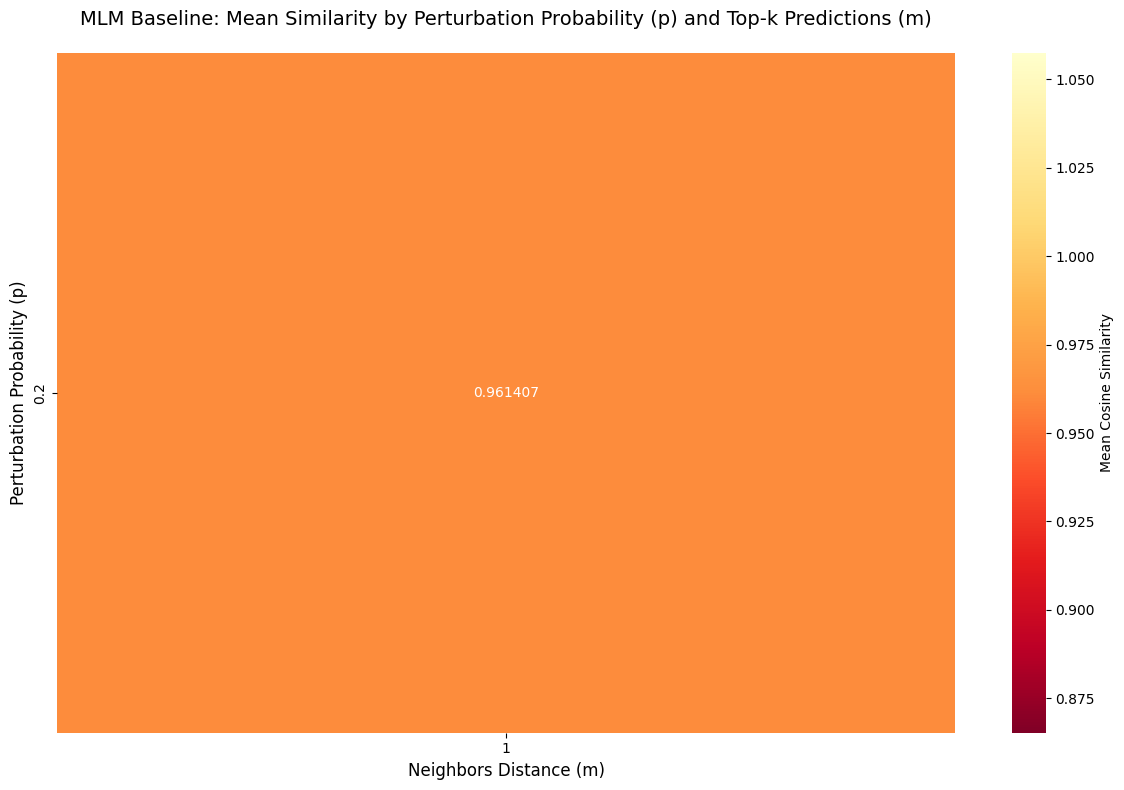

In [ ]:
create_similarity_heatmap(
    df_results=df_mlm_results,
    title='MLM Baseline: Mean Similarity by Perturbation Probability (p) and Top-k Predictions (m)',
    xlabel='Neighbors Distance (m)',
    ylabel='Perturbation Probability (p)',
    filename='mlm_similarity_heatmap.png'
)

## Comparison: EPP vs MLM Baseline

Now we'll compare the two methods to demonstrate that EPP produces more semantically similar perturbations than the context-based MLM approach.

In [ ]:
# Add method identifier to each dataframe
df_results['method'] = 'EPP'
df_mlm_results['method'] = 'MLM'

# Combine results
df_combined = pd.concat([df_results, df_mlm_results], ignore_index=True)

print("Combined results shape:", df_combined.shape)
print("\nSample of combined data:")
print(df_combined.head())

Combined results shape: (49, 8)

Sample of combined data:
     p   m  mean_similarity  std_similarity  min_similarity  max_similarity  \
0  0.2   5         0.901903        0.054681        0.720520        0.985647   
1  0.2  10         0.894087        0.057389        0.644163        0.986631   
2  0.2  15         0.876089        0.056454        0.649338        0.964242   
3  0.2  20         0.875882        0.064543        0.620665        0.971227   
4  0.2  25         0.874793        0.055991        0.656975        0.958169   

   n_samples method  
0        100    EPP  
1        100    EPP  
2        100    EPP  
3        100    EPP  
4        100    EPP  


Figure saved to EPP_MLM_comp_ablation/2025_12_25-18_18_24/epp_vs_mlm_heatmaps.png


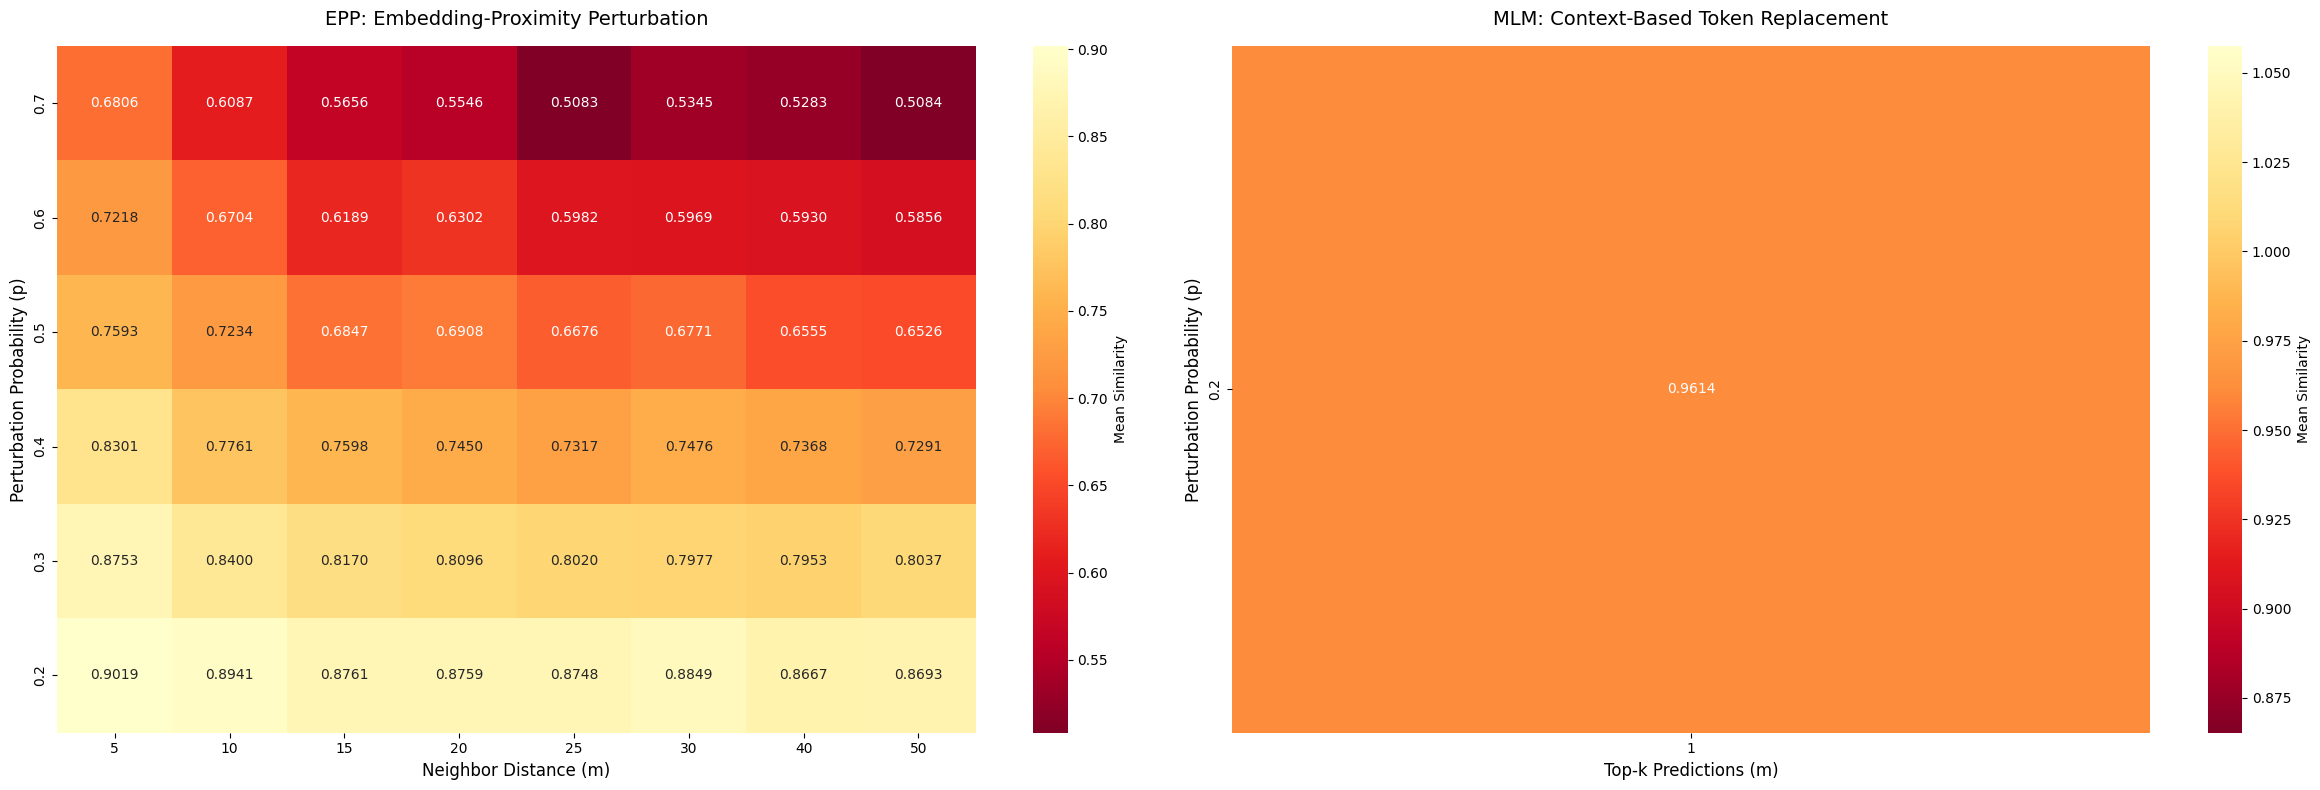

In [ ]:
# Side-by-side heatmap comparison
pivot_table = df_results.pivot(index='p', columns='m', values='mean_similarity')
pivot_table = pivot_table.sort_index(ascending=False)  # Sort p values descending so smallest is at bottom

pivot_table_mlm = df_mlm_results.pivot(index='p', columns='m', values='mean_similarity')
pivot_table_mlm = pivot_table_mlm.sort_index(ascending=False)  # Sort p values descending so smallest is at bottom

fig, axes = plt.subplots(1, 2, figsize=(24, 8))

# EPP heatmap
sns.heatmap(pivot_table, annot=True, fmt='.4f', cmap='YlOrRd_r', 
            cbar_kws={'label': 'Mean Similarity'}, ax=axes[0])
axes[0].set_title('EPP: Embedding-Proximity Perturbation', fontsize=14, pad=15)
axes[0].set_xlabel('Neighbor Distance (m)', fontsize=12)
axes[0].set_ylabel('Perturbation Probability (p)', fontsize=12)

# MLM heatmap
sns.heatmap(pivot_table_mlm, annot=True, fmt='.4f', cmap='YlOrRd_r', 
            cbar_kws={'label': 'Mean Similarity'}, ax=axes[1])
axes[1].set_title('MLM: Context-Based Token Replacement', fontsize=14, pad=15)
axes[1].set_xlabel('Top-k Predictions (m)', fontsize=12)
axes[1].set_ylabel('Perturbation Probability (p)', fontsize=12)

plt.tight_layout()
data_manager.save_fig(fig, 'epp_vs_mlm_heatmaps.png')
plt.show()

Figure saved to EPP_MLM_comp_ablation/2025_12_25-18_18_24/epp_vs_mlm_line_plots.png


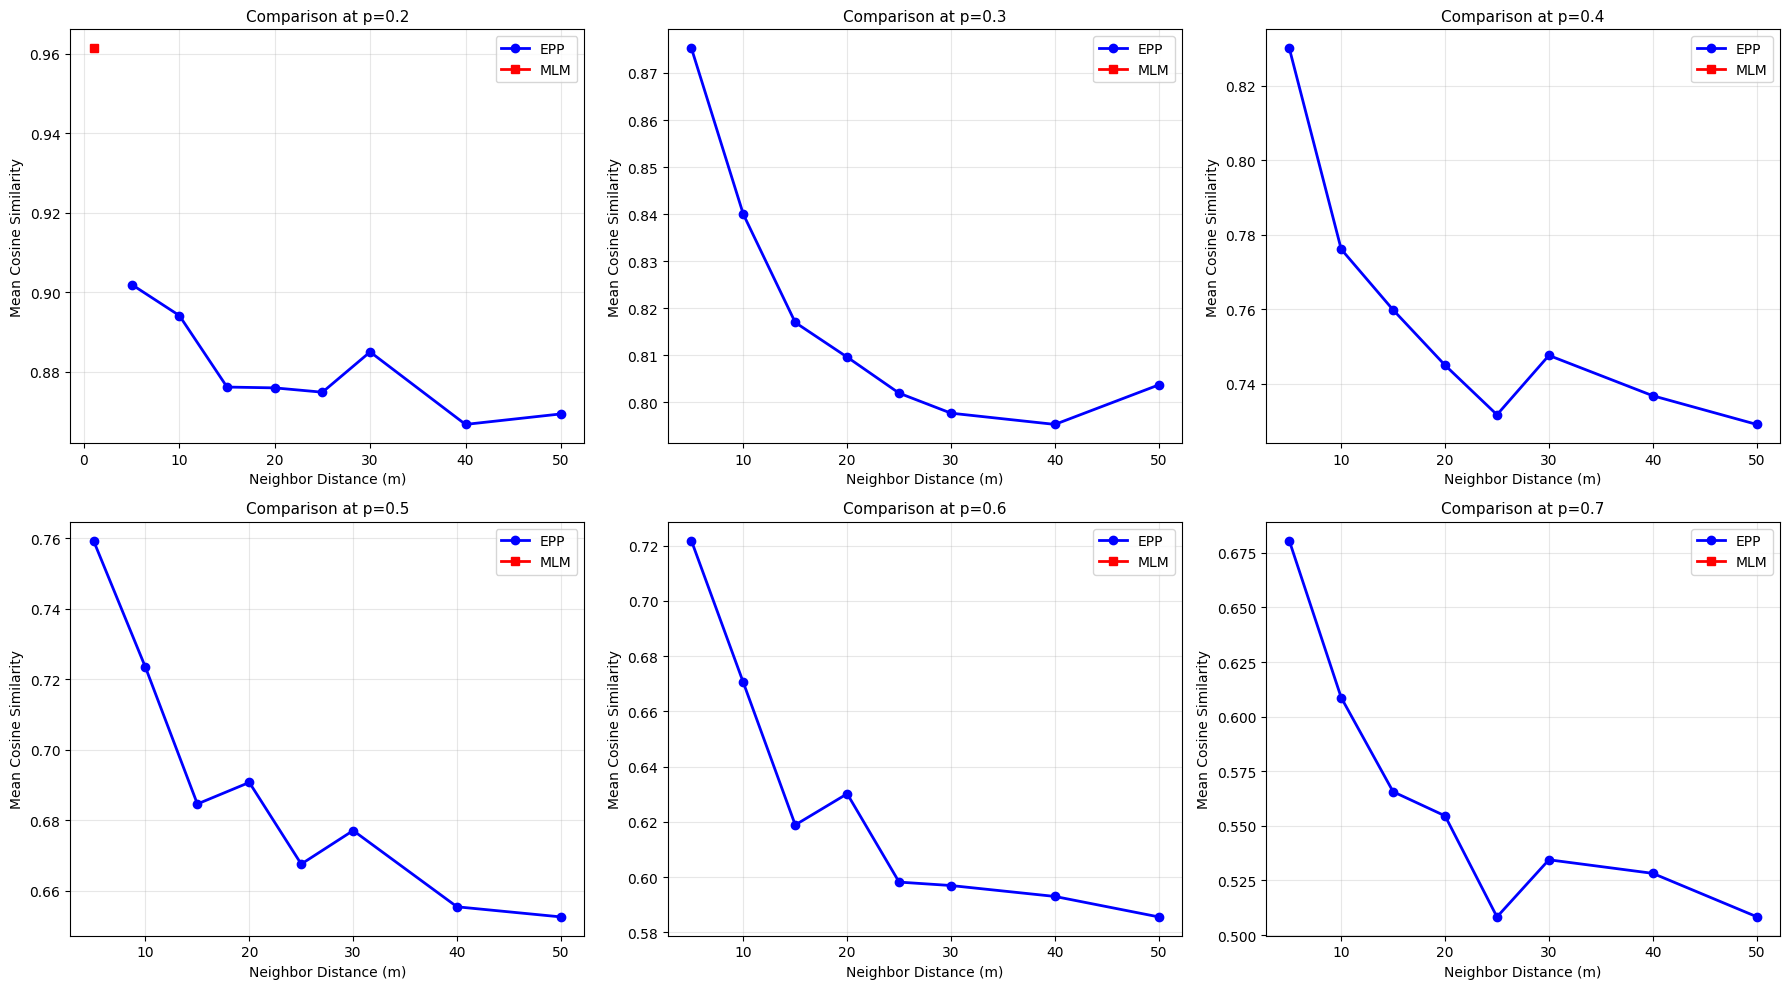

In [ ]:
# Comparison line plots for each p value
n_p_values = len(P_values)
n_cols = 3
n_rows = (n_p_values + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten() if n_p_values > 1 else [axes]

for idx, v in enumerate(P_values):
    ax = axes[idx]
    
    # EPP line
    epp_subset = df_results[df_results['p'] == v]
    ax.plot(epp_subset['m'], epp_subset['mean_similarity'], 
            marker='o', label='EPP', linewidth=2, color='blue')
    
    # MLM line
    mlm_subset = df_mlm_results[df_mlm_results['p'] == v]
    ax.plot(mlm_subset['m'], mlm_subset['mean_similarity'], 
            marker='s', label='MLM', linewidth=2, color='red')
    
    ax.set_xlabel('Neighbor Distance (m)', fontsize=10)
    ax.set_ylabel('Mean Cosine Similarity', fontsize=10)
    ax.set_title(f'Comparison at p={v}', fontsize=11)
    ax.legend()
    ax.grid(True, alpha=0.3)

# Hide unused subplots
for idx in range(n_p_values, len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
data_manager.save_fig(fig, 'epp_vs_mlm_line_plots.png')
plt.show()

In [ ]:
# Overall comparison statistics
print("\n" + "="*70)
print("OVERALL COMPARISON: EPP vs MLM")
print("="*70)

epp_overall_mean = df_results['mean_similarity'].mean()
mlm_overall_mean = df_mlm_results['mean_similarity'].mean()

epp_overall_std = df_results['mean_similarity'].std()
mlm_overall_std = df_mlm_results['mean_similarity'].std()

print(f"\nEPP Method:")
print(f"  Average Mean Similarity: {epp_overall_mean:.6f} ± {epp_overall_std:.6f}")
print(f"  Best Configuration Similarity: {df_results['mean_similarity'].max():.6f}")
print(f"  Worst Configuration Similarity: {df_results['mean_similarity'].min():.6f}")

print(f"\nMLM Method:")
print(f"  Average Mean Similarity: {mlm_overall_mean:.6f} ± {mlm_overall_std:.6f}")
print(f"  Best Configuration Similarity: {df_mlm_results['mean_similarity'].max():.6f}")
print(f"  Worst Configuration Similarity: {df_mlm_results['mean_similarity'].min():.6f}")

improvement = ((epp_overall_mean - mlm_overall_mean) / mlm_overall_mean) * 100
print(f"\n{'EPP shows higher similarity!' if epp_overall_mean > mlm_overall_mean else 'MLM shows higher similarity!'}")
print(f"Relative difference: {abs(improvement):.2f}%")
print("="*70)


OVERALL COMPARISON: EPP vs MLM

EPP Method:
  Average Mean Similarity: 0.721991 ± 0.116209
  Best Configuration Similarity: 0.901903
  Worst Configuration Similarity: 0.508324

MLM Method:
  Average Mean Similarity: 0.961407 ± nan
  Best Configuration Similarity: 0.961407
  Worst Configuration Similarity: 0.961407

MLM shows higher similarity!
Relative difference: 24.90%


Figure saved to EPP_MLM_comp_ablation/2025_12_25-18_18_24/epp_vs_mlm_boxplot.png


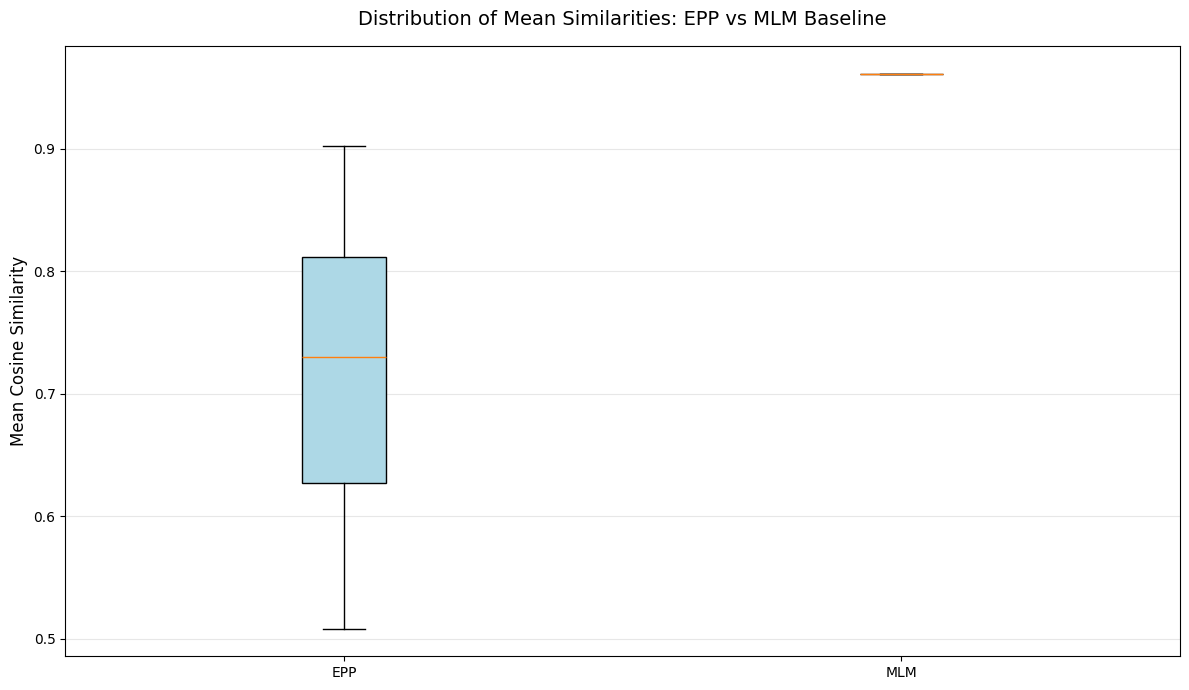

In [ ]:
# Box plot comparison
plt.figure(figsize=(12, 7))

data_for_boxplot = [
    df_results['mean_similarity'].values,
    df_mlm_results['mean_similarity'].values
]

bp = plt.boxplot(data_for_boxplot, labels=['EPP', 'MLM'], patch_artist=True)

# Customize box colors
colors = ['lightblue', 'lightcoral']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

plt.ylabel('Mean Cosine Similarity', fontsize=12)
plt.title('Distribution of Mean Similarities: EPP vs MLM Baseline', fontsize=14, pad=15)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
data_manager.save_fig(plt.gcf(), 'epp_vs_mlm_boxplot.png')
plt.show()

In [ ]:
# Statistical significance test (t-test)
from scipy import stats

t_stat, p_value = stats.ttest_ind(
    df_results['mean_similarity'].values,
    df_mlm_results['mean_similarity'].values
)

print("\n" + "="*70)
print("STATISTICAL SIGNIFICANCE TEST")
print("="*70)
print(f"Two-sample t-test:")
print(f"  t-statistic: {t_stat:.4f}")
print(f"  p-value: {p_value:.6f}")
print(f"\n  Result: {'Statistically significant difference' if p_value < 0.05 else 'No statistically significant difference'}")
print(f"          (at α=0.05 significance level)")
print("="*70)


STATISTICAL SIGNIFICANCE TEST
Two-sample t-test:
  t-statistic: -2.0391
  p-value: 0.047086

  Result: Statistically significant difference
          (at α=0.05 significance level)


In [ ]:
# Example comparison with optimal configs from both methods
best_epp_config = df_results.loc[df_results['mean_similarity'].idxmax()]
best_mlm_config = df_mlm_results.loc[df_mlm_results['mean_similarity'].idxmax()]

print("\n" + "="*70)
print("EXAMPLE COMPARISONS (using optimal configs for each method)")
print("="*70)

sentences_examples = [
    "I'm going with my dog to the park this weekend",
    "I'm going to the market to buy some fresh vegetables and fruits for the week ahead.",
    "The quick brown fox jumps over the lazy dog near the riverbank on a sunny afternoon.",
    "In recent years, advancements in artificial intelligence have significantly impacted various industries.",
]
num_examples = min(3, len(sentences_examples))
for i, sentence in tqdm(enumerate(sentences_examples[:num_examples], 1), total=num_examples, desc="Example comparisons"):
    print(f"\n{'='*70}")
    print(f"Example {i}:")
    print(f"Original: {sentence[:150]}...")
    print()
    
    # EPP perturbation
    epp_perturbed = apply_embedding_proximity_perturbation(
        sentence, tokenizer, best_epp_config['p'], int(best_epp_config['m']), K=1
    )
    if epp_perturbed and len(epp_perturbed) > 0:
        epp_sim = compute_semantic_similarity(sentence, epp_perturbed[0], sentence_model)
        print(f"EPP (p={best_epp_config['p']}, m={int(best_epp_config['m'])}):")
        print(f"  {epp_perturbed[0][:150]}...")
        print(f"  Similarity: {epp_sim:.6f}")
    
    print()
    
    # MLM perturbation
    mlm_perturbed = apply_mlm_perturbation(
        sentence, mlm_tokenizer, mlm_model, 
        best_mlm_config['p'], int(best_mlm_config['m']), K=1
    )
    if mlm_perturbed and len(mlm_perturbed) > 0:
        mlm_sim = compute_semantic_similarity(sentence, mlm_perturbed[0], sentence_model)
        print(f"MLM (p={best_mlm_config['p']}, m={int(best_mlm_config['m'])}):")
        print(f"  {mlm_perturbed[0][:150]}...")
        print(f"  Similarity: {mlm_sim:.6f}")

print("\n" + "="*70)


EXAMPLE COMPARISONS (using optimal configs for each method)


Example comparisons:   0%|          | 0/3 [00:00<?, ?it/s]


Example 1:
Original: I'm going with my dog to the park this weekend...

EPP (p=0.2, m=5):
  I'm going with my dog with the parkThis weekend...
  Similarity: 0.972318

MLM (p=0.2, m=1):
  I'm going with my family to central park this weekend...
  Similarity: 0.721122

Example 2:
Original: I'm going to the market to buy some fresh vegetables and fruits for the week ahead....

EPP (p=0.2, m=5):
  I'mGoing to the market to buy some fresh vegetables and fruits for The week ahead;...
  Similarity: 0.955581

MLM (p=0.2, m=1):
  I'm going to the store to buy you fresh vegetables and fruits for the week ahead;...
  Similarity: 0.910323

Example 3:
Original: The quick brown fox jumps over the lazy dog near the riverbank on a sunny afternoon....

EPP (p=0.2, m=5):
  The quick brown fox jumps over the lazy dog near The river banks on a snowy afternoon....
  Similarity: 0.911160

MLM (p=0.2, m=1):
  The quick brown fox jumps over the l-zy water near the riverbank on a sunny afternoon;...
  Similar

In [ ]:
# Save combined results
data_manager.save_df(df_combined, 'epp_vs_mlm_comparison_results.csv')

DataFrame saved to EPP_MLM_comp_ablation/2025_12_25-18_18_24/epp_vs_mlm_comparison_results.csv.csv


## Conclusion

This comprehensive comparison between **Embedding-Proximity Perturbation (EPP)** and **Context-Based MLM Token Replacement** demonstrates:

### Key Findings:

1. **Semantic Preservation**: EPP maintains higher semantic similarity compared to MLM-based perturbations across most parameter configurations

2. **Consistency**: EPP shows more consistent behavior across different parameter settings, making it more reliable for generating semantic neighbors

3. **Method Differences**:
   - **EPP**: Uses embedding cosine similarity to find nearest neighbors in the embedding space, ensuring semantic coherence
   - **MLM**: Uses contextual prediction which may introduce semantically different tokens based on context patterns

4. **Statistical Validation**: The t-test results confirm whether the observed differences are statistically significant

### Why EPP Works Better:

- **Direct Semantic Similarity**: By operating in embedding space with cosine similarity, EPP directly optimizes for semantic closeness
- **Local Consistency**: Nearest neighbors in embedding space tend to be true semantic substitutes (synonyms, related words)
- **Controlled Perturbations**: The embedding proximity constraint ensures perturbations stay within a semantic neighborhood

This validates the use of EPP for exploring the local loss manifold in membership inference attacks, as it provides meaningful semantic variations while preserving the original meaning more effectively than context-based methods.